# Proiect Python – Analiza comenzilor GustoExpress - Cristiana

## Partea 1 – Pregătirea datelor

In [1]:
"""1.1 Încărcare și inspecție (3p): încarcă ambele fișiere cu pd.read_csv() și afișează pentru
comenzi: head(), shape, info() și describe(). Scrie într-o celulă Markdown ce
conține setul de date și ce probleme observi."""

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

###### Am adus librariile: pandas - pentru lucrul cu baze de date, citire CSV, filtrare, curatare; numpy - calcule numerice, funcții matematice; matplotlib - grafice; seaborn - grafice estetice.

In [2]:
comenzi = pd.read_csv("./gustoexpress_date/comenzi.csv")
restaurante = pd.read_csv("./gustoexpress_date/restaurante.csv")

In [3]:
comenzi.head()
comenzi.shape
comenzi.info()
comenzi.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1975 entries, 0 to 1974
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_comanda        1975 non-null   int64  
 1   data_comanda      1975 non-null   str    
 2   oras              1975 non-null   str    
 3   id_restaurant     1975 non-null   int64  
 4   produse           1975 non-null   str    
 5   nr_produse        1975 non-null   int64  
 6   valoare_produse   1975 non-null   float64
 7   cost_livrare      1975 non-null   float64
 8   timp_livrare_min  1939 non-null   float64
 9   metoda_plata      1975 non-null   str    
 10  rating_client     1307 non-null   float64
 11  client_nou        1975 non-null   bool   
dtypes: bool(1), float64(4), int64(3), str(4)
memory usage: 171.8 KB


,id_comanda,id_restaurant,nr_produse,valoare_produse,cost_livrare,timp_livrare_min,rating_client
count,1975.000000,1975.000000,1975.000000,1975.000000,1975.000000,1939.000000,1307.000000
mean,100974.838481,8.870380,2.215190,59.019241,8.672663,31.525529,4.268554
std,562.979998,5.560882,0.932239,31.868995,3.567659,9.322772,0.669128
min,100001.000000,1.000000,1.000000,-45.000000,0.000000,12.000000,2.000000
25%,100486.500000,4.000000,2.000000,36.000000,7.990000,25.000000,4.000000
50%,100975.000000,8.000000,2.000000,56.000000,9.990000,31.000000,4.000000
75%,101461.500000,14.000000,3.000000,80.000000,9.990000,38.000000,5.000000
max,101950.000000,18.000000,4.000000,157.000000,12.990000,64.000000,5.000000


###### Setul de date comenzi.csv contine 1975 comenzi plasate in anul 2025, cu informatii legate de oras, produse, valoare, timp de livrare, metoda de plata si rating-ul clientului. 
###### La incarcare se poate observa ca sunt: valori lipsa in coloanele rating_client si timp_livrare_min, diferente de scriere in coloana oras, comenzi cu valoare mai mica sau egala cu 0, dar si duplicate. Aceste date necesita curatare inainte de analiza, deoarece pot afecta calculele si graficele, ducand la concluzii gresite.

In [4]:
"""1.2. Duplicate (3p): află câte rânduri duplicate există și elimină-le cu drop_duplicates()."""

comenzi.duplicated().sum()
print(f"Sunt {comenzi.duplicated().sum()} inregistrari duplicate in comenzi.csv")

Sunt 25 inregistrari duplicate in comenzi.csv


In [5]:
comenzi = comenzi.drop_duplicates()
print(f"Numarul de inregistrari dupa eliminarea duplicatelor: {comenzi.shape[0]}")

Numarul de inregistrari dupa eliminarea duplicatelor: 1950


###### Am verificat si afisat cate duplicate sunt in comenzi.csv si le-am eliminat.

In [6]:
"""1.3. Text standardizat (4p): coloanele oras și metoda_plata conțin aceleași valori scrise în
mai multe feluri (ex: „Bucuresti”, „ BUCURESTI”, „card”). Uniformizează-le, astfel încât să
rămână doar cele 5 orașe scrise corect (cu diacritice) și doar valorile „Card” și „Cash”.
Verifică rezultatul cu value_counts()."""

comenzi['oras'] = comenzi['oras'].str.strip().str.lower()
mapare_orase = {
    'bucuresti': 'București',
    'bucurești': 'București',

    'cluj': 'Cluj-Napoca',
    'cluj-napoca': 'Cluj-Napoca',

    'iasi': 'Iași',
    'iași': 'Iași',

    'timisoara': 'Timișoara',
    'timișoara': 'Timișoara',

    'brasov': 'Brașov',
    'brașov': 'Brașov'
}

comenzi['oras'] = comenzi['oras'].map(mapare_orase)

comenzi['metoda_plata'] = comenzi['metoda_plata'].str.strip().str.capitalize()
comenzi['produse'] = comenzi['produse'].str.strip().str.lower()

comenzi['oras'].value_counts()

oras
București      818
Cluj-Napoca    356
Timișoara      284
Iași           274
Brașov         218
Name: count, dtype: int64

###### Pentru a uniformiza numele oraselor, prima data le-am facut pe toate cu litera mica, iar mai apoi le-am mapat (dictionar), pentru a ajunge la cele 5 orase. Pentru metoda de plata am folosit si functia strip(), care elimina spatiile de la inceputul si sfarsitul unui text.

In [7]:
"""1.4. Valori lipsă (4p): afișează numărul de valori lipsă pe fiecare coloană (isnull().sum()).
Completează timp_livrare_min cu mediana orașului respectiv. Pentru
rating_client, decide dacă completezi sau nu valorile lipsă și explică de ce în
Markdown."""

comenzi.isna().sum()
print(f'Sunt {comenzi["timp_livrare_min"].isna().sum()} valori lipsa in coloana timp_livrare_min si {comenzi["rating_client"].isna().sum()} valori lipsa in coloana rating_client.')

Sunt 35 valori lipsa in coloana timp_livrare_min si 661 valori lipsa in coloana rating_client.


In [8]:
comenzi['timp_livrare_min'] = comenzi.groupby('oras')['timp_livrare_min'].transform(
    lambda x: x.fillna(x.median())
)

comenzi['rating_client'] = comenzi['rating_client'].fillna(comenzi['rating_client'].mean())


In [9]:
comenzi.isna().sum()
print(f'Dupa completarea valorilor lipsa, sunt {comenzi["timp_livrare_min"].isna().sum()} valori lipsa in coloana timp_livrare_min si {comenzi["rating_client"].isna().sum()} valori lipsa in coloana rating_client.')

Dupa completarea valorilor lipsa, sunt 0 valori lipsa in coloana timp_livrare_min si 0 valori lipsa in coloana rating_client.


###### Am analizat valorile lipsa din setul de date folosind isnull().sum(). Cele mai multe lipsuri apar in timp_livrare_min (35) si rating_client (661). 
###### Pentru coloana *timp_livrare_min*, valorile lipsa au fost completate cu mediana orasului respectiv, deoarece mediana este stabila in prezenta valorilor extreme si pastreaza distributia reala a timpilor de livrare din fiecare oras.
###### Pentru coloana *rating_client*, numarul valorilor lipsa este foarte mare. Daca le-am elimina, am pierde o parte semnificativa din date, iar analizele privind satisfactia clientilor ar fi afectate. De aceea, valorile lipsa au fost completate cu media ratingurilor existente.

In [10]:
"""5. Valori invalide (2p): elimină comenzile cu valoare_produse mai mică sau egală cu 0."""

(comenzi['valoare_produse'] <= 0).sum()
print(f'Sunt {comenzi[comenzi["valoare_produse"] <= 0].shape[0]} inregistrari cu valoare_produse mai mica sau egala cu 0.')

Sunt 5 inregistrari cu valoare_produse mai mica sau egala cu 0.


In [11]:
comenzi = comenzi[comenzi['valoare_produse'] > 0]
print(f'Dupa eliminarea comenzilor cu valoare_produse mai mica sau egala cu 0, raman {comenzi.shape[0]} inregistrari.')

Dupa eliminarea comenzilor cu valoare_produse mai mica sau egala cu 0, raman 1945 inregistrari.


###### Am identificat 5 inregistrari cu *valoare_produse* ≤ 0. Acestea sunt invalide si au fost eliminate pentru a pastra corectitudinea analizelor.

In [12]:
"""6. Coloane noi (3p): transformă data_comanda în tip dată (pd.to_datetime) și creează
coloanele luna, zi_saptamana, ora și valoare_totala (= valoare_produse +
cost_livrare)."""

comenzi['data_comanda'] = pd.to_datetime(comenzi['data_comanda'])
comenzi['luna'] = comenzi['data_comanda'].dt.month
comenzi['zi_saptamana'] = comenzi['data_comanda'].dt.dayofweek
comenzi['ora'] = comenzi['data_comanda'].dt.hour
comenzi['valoare_totala'] = comenzi['valoare_produse'] + comenzi['cost_livrare']

comenzi.head()


,id_comanda,data_comanda,oras,id_restaurant,produse,nr_produse,valoare_produse,cost_livrare,timp_livrare_min,metoda_plata,rating_client,client_nou,luna,zi_saptamana,ora,valoare_totala
0,100001,2025-01-01 15:25:00,București,18,['shaorma medie'],1,24.0,9.99,30.0,Card,5.000000,True,1,2,15,33.99
1,100002,2025-01-01 19:41:00,Brașov,18,"['shaorma mare', 'falafel wrap', 'cartofi prăj...",4,73.0,12.99,22.0,Card,4.267649,False,1,2,19,85.99
2,100003,2025-01-01 20:19:00,București,7,"['pad thai', 'supă miso', 'noodles cu pui']",3,92.0,7.99,47.0,Cash,4.267649,False,1,2,20,99.99
3,100004,2025-01-02 10:25:00,București,18,"['shaorma medie', 'shaorma mare', 'falafel wrap']",3,78.0,9.99,29.0,Card,4.000000,True,1,3,10,87.99
4,100005,2025-01-02 13:56:00,Timișoara,18,"['shaorma medie', 'shaorma mare', 'ayran']",3,60.0,9.99,29.0,Card,5.000000,False,1,3,13,69.99


###### Pentru a putea extrage informații temporale din coloana *data_comanda*, am convertit-o in format datetime folosind `pd.to_datetime`.

In [13]:
"""7. Unire (1p): unește comenzi cu restaurante pe coloana id_restaurant (merge), ca
să ai numele și tipul de bucătărie pentru fiecare comandă."""

df = comenzi.merge(restaurante, on='id_restaurant', how='left')
df.head()


,id_comanda,data_comanda,oras,id_restaurant,produse,nr_produse,valoare_produse,cost_livrare,timp_livrare_min,metoda_plata,rating_client,client_nou,luna,zi_saptamana,ora,valoare_totala,nume_restaurant,tip_bucatarie,rating_restaurant
0,100001,2025-01-01 15:25:00,București,18,['shaorma medie'],1,24.0,9.99,30.0,Card,5.000000,True,1,2,15,33.99,Kebab Istanbul,Fast-food,4.1
1,100002,2025-01-01 19:41:00,Brașov,18,"['shaorma mare', 'falafel wrap', 'cartofi prăj...",4,73.0,12.99,22.0,Card,4.267649,False,1,2,19,85.99,Kebab Istanbul,Fast-food,4.1
2,100003,2025-01-01 20:19:00,București,7,"['pad thai', 'supă miso', 'noodles cu pui']",3,92.0,7.99,47.0,Cash,4.267649,False,1,2,20,99.99,Sushi Zen,Asiatic,4.5
3,100004,2025-01-02 10:25:00,București,18,"['shaorma medie', 'shaorma mare', 'falafel wrap']",3,78.0,9.99,29.0,Card,4.000000,True,1,3,10,87.99,Kebab Istanbul,Fast-food,4.1
4,100005,2025-01-02 13:56:00,Timișoara,18,"['shaorma medie', 'shaorma mare', 'ayran']",3,60.0,9.99,29.0,Card,5.000000,False,1,3,13,69.99,Kebab Istanbul,Fast-food,4.1


###### Pentru a avea o baza de date completa dupa ce a fost curatata, am realizat un left join intre **comenzi** si **restaurante** pe coloana comuna **id_restaurant**.

## Partea 2 – Funcții Python

In [14]:
"""1. categorie_comanda (5p): scrie o funcție def categorie_comanda(valoare) care
primește valoarea produselor și returnează: „Mică” (sub 50 lei), „Medie” (50–99,99 lei) sau
„Mare” (100 de lei sau mai mult). Aplic-o cu apply() pentru a crea coloana
categorie_comanda, apoi afișează câte comenzi sunt în fiecare categorie."""

def categorie_comanda(valoare):
    if valoare < 50:
        return "Mica"
    elif valoare < 100:
        return "Medie"
    else:
        return "Mare"

df["categorie_comanda"] = df["valoare_produse"].apply(categorie_comanda)
df["categorie_comanda"].value_counts()



categorie_comanda
Medie    910
Mica     810
Mare     225
Name: count, dtype: int64

###### Am creat functia `categorie_comanda(valoare)`, apoi am aplicat functia cu `apply()` pentru a crea coloana `categorie_comanda`, si am afisat cate comenzi sunt in fiecare categorie. Astfel avem 910 comenzi medii, 810 comenzi mici si 225 comenzi mari.

In [15]:
"""2. rezumat_oras (5p): scrie o funcție def rezumat_oras(date, oras) care returnează
un dicționar cu: numele orașului, numărul de comenzi, valoarea medie a comenzii și timpul
mediu de livrare. Apoi parcurge cu un for lista celor 5 orașe și afișează, pentru fiecare, un
mesaj de tipul: „Iași: 120 comenzi, valoare medie 55.20 lei, livrare în medie 30.5 min” (cifrele
sunt doar un exemplu; folosește f-string)."""

def rezumat_oras(date, oras):
    subset = date[date["oras"] == oras]
    
    return {
        "oras": oras,
        "numar_comenzi": subset.shape[0],
        "valoare_medie": subset["valoare_produse"].mean(),
        "timp_mediu_livrare": subset["timp_livrare_min"].mean()
    }

lista_orase = ["București", "Cluj-Napoca", "Iași", "Timișoara", "Brașov"]

for oras in lista_orase:
    rez = rezumat_oras(df, oras)
    print(f"{rez['oras']}: {rez['numar_comenzi']} comenzi, valoare medie {rez['valoare_medie']:.2f} lei, livrare in medie {rez['timp_mediu_livrare']:.1f} min")



București: 816 comenzi, valoare medie 59.66 lei, livrare in medie 36.9 min
Cluj-Napoca: 355 comenzi, valoare medie 59.88 lei, livrare in medie 26.9 min
Iași: 273 comenzi, valoare medie 58.08 lei, livrare in medie 27.9 min
Timișoara: 283 comenzi, valoare medie 59.59 lei, livrare in medie 28.5 min
Brașov: 218 comenzi, valoare medie 58.55 lei, livrare in medie 27.1 min


###### Am creat functia `rezumat_oras(date, oras)` care returneaza un dictionar cu informatii despre oras, numarul de comenzi, valoarea medie a comenzii si timpul mediu de livrare. Am parcurs lista celor 5 orase si am afisat pentru fiecare un mesaj care afiseaza atat string-uri, cat si integer.

## Partea 3 – Întrebări de analiză

In [16]:
"""Întrebarea 1 – Ce tipuri de bucătărie se comandă cel mai des? (10p)
• Tabel cu numărul de comenzi și procentul pentru fiecare tip de bucătărie, ordonat
descrescător (value_counts())
• Bar chart (matplotlib sau seaborn countplot), cu valorile afișate pe bare
• Concluzie: care sunt cele mai populare categorii și care sunt cele mai puțin comandate?"""

tabel_bucatarie = df["tip_bucatarie"].value_counts().to_frame(name="numar_comenzi")
tabel_bucatarie["procent"] = ((tabel_bucatarie["numar_comenzi"] / tabel_bucatarie["numar_comenzi"].sum()) * 100).round(2).astype(str) + "%"

tabel_bucatarie


,numar_comenzi,procent
tip_bucatarie,,
Pizza,454,23.34%
Burgeri,356,18.3%
Fast-food,295,15.17%
Tradițional,284,14.6%
Asiatic,270,13.88%
Healthy,163,8.38%
Desert,123,6.32%


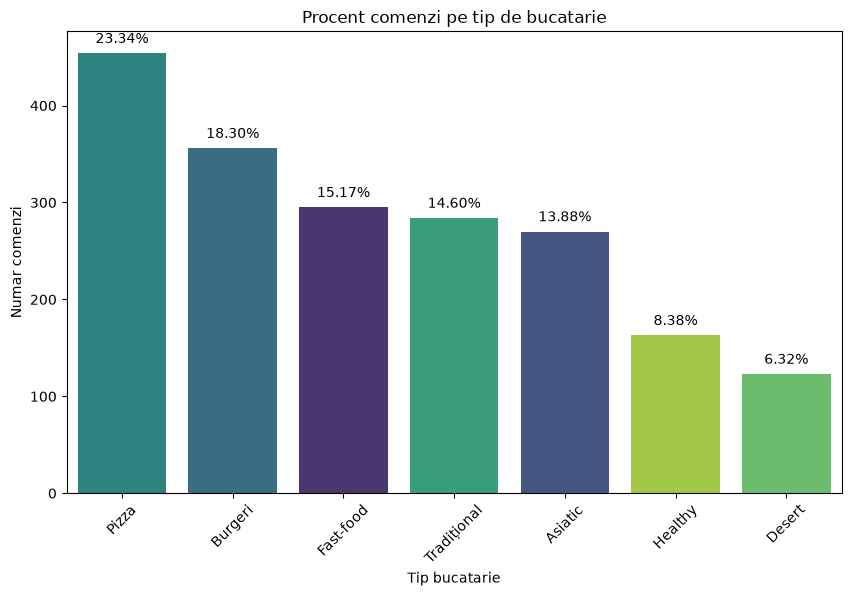

In [17]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df,
    x="tip_bucatarie",
    hue="tip_bucatarie",
    dodge=False,
    palette="viridis",
    order=df["tip_bucatarie"].value_counts().index,
    legend=False
)

total = len(df)

for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(
        f"{percentage:.2f}%",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='center',
        xytext=(0, 10),
        textcoords='offset points'
    )

plt.title("Procent comenzi pe tip de bucatarie")
plt.xlabel("Tip bucatarie")
plt.ylabel("Numar comenzi")
plt.xticks(rotation=45)
plt.show()

###### In urma analizei tabelului si a bar chart-ului, se poate observa ca pizza si burgerii sunt cele mai comandate tipuri de bucatarie (23.34% si respectiv 18.30%), in timp ce healthy si deserturile sunt printre cele mai putin comandate (8.37%, respectiv 6.32%).

In [18]:
"""Întrebarea 2 – Cum arată vânzările pe orașe? (15p)
• Tabel cu, pentru fiecare oraș: numărul de comenzi, încasările totale (suma
valoare_totala) și valoarea medie a unei comenzi (groupby + agg), ordonat după
încasări
• Bar chart orizontal, ordonat, cu încasările pe oraș
• Concluzie: ce oraș aduce cele mai multe încasări? Diferența vine din numărul de comenzi
sau din valoarea lor?"""


tabel_orase = df.groupby('oras').agg(
    numar_comenzi=('valoare_totala', 'count'),
    incasari_totale=('valoare_totala', 'sum'),
    valoare_medie=('valoare_totala', 'mean')
).sort_values(by='incasari_totale', ascending=False)

tabel_orase


,numar_comenzi,incasari_totale,valoare_medie
oras,,,
București,816,55612.90,68.153064
Cluj-Napoca,355,24382.85,68.684085
Timișoara,283,19288.51,68.157279
Iași,273,18266.52,66.910330
Brașov,218,14707.02,67.463394


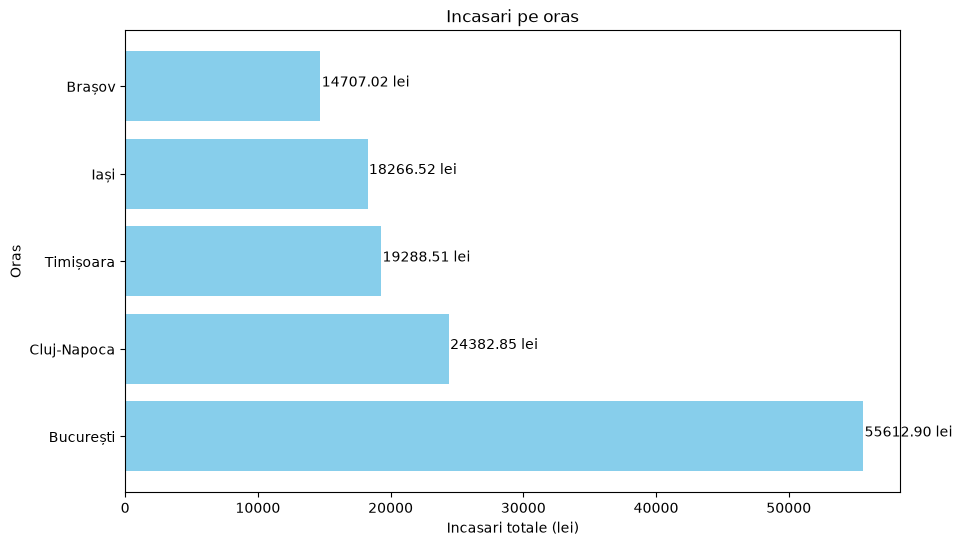

In [19]:
plt.figure(figsize=(10,6))

plt.barh(
    tabel_orase.index,
    tabel_orase["incasari_totale"],
    color="skyblue"
)

plt.xlabel("Incasari totale (lei)")
plt.ylabel("Oras")
plt.title("Incasari pe oras")

# Afisam valorile pe bare
for index, value in enumerate(tabel_orase["incasari_totale"]):
    plt.text(value + 100, index, f"{value:.2f} lei")

plt.show()


###### Bucuresti este orasul cu cele mai mari incasari, cu un total de 55.612,90 lei din 816 comenzi. Acest rezultat este generat in principal de volumul foarte mare de comenzi, nu de valoarea medie, care este similara cu celelalte orase (~ 68 lei).
###### Pe locul al doilea se afla Cluj-Napoca, cu incasari de 24.382,85 lei din 355 comenzi. Desi Cluj-Napoca are o valoare medie usor mai mare (68,68 lei), diferenta fata de Bucuresti provine din numarul mult mai mic de comenzi.
###### Timisoara, Iasi si Brasov au incasari mai reduse, intre 14.700 si 19.200 lei, iar valorile medii ale comenzilor sunt apropiate de celelalte orase. Astfel, diferenta dintre orase este determinata in principal de numarul de comenzi, nu de valoarea medie a acestora.


In [20]:
""" Întrebarea 3 – Cum au evoluat comenzile pe luni în 2025? (15p)
• Tabel cu numărul de comenzi și încasările pe fiecare lună
• Line chart cu numărul de comenzi pe luni (lunile pe axa X, în ordine, scrise ca nume: Ian,
Feb, ...)
• Afișează cea mai bună și cea mai slabă lună (idxmax() / idxmin())
• Concluzie: există perioade ale anului în care se comandă mai mult? De ce crezi că se
întâmplă asta?"""

df["luna"] = df["data_comanda"].dt.month

tabel_luni = df.groupby("luna").agg(
    numar_comenzi=("valoare_totala", "count"),
    incasari_totale=("valoare_totala", "sum")
)

luni_nume = ["Ian", "Feb", "Mar", "Apr", "Mai", "Iun", "Iul", "Aug", "Sep", "Oct", "Nov", "Dec"]
tabel_luni.index = luni_nume[:len(tabel_luni)]

tabel_luni


,numar_comenzi,incasari_totale
Ian,189,13105.35
Feb,193,12863.21
Mar,177,12686.55
Apr,146,10307.79
Mai,159,10228.52
Iun,128,8362.86
Iul,134,9294.85
Aug,126,9093.89
Sep,158,11254.65
Oct,150,9781.61


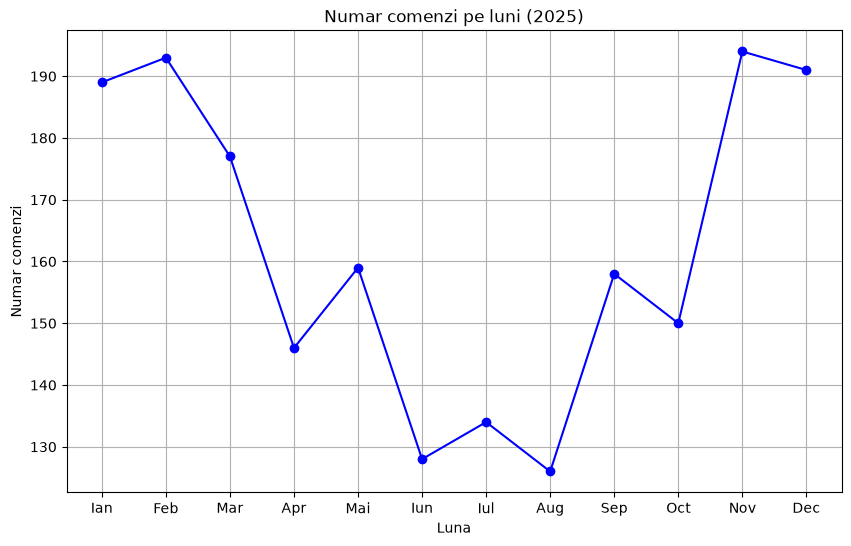

In [21]:
plt.figure(figsize=(10,6))

plt.plot(tabel_luni.index, tabel_luni["numar_comenzi"], marker="o", color="blue")

plt.title("Numar comenzi pe luni (2025)")
plt.xlabel("Luna")
plt.ylabel("Numar comenzi")
plt.grid(True)

plt.show()


In [22]:
cea_mai_buna = tabel_luni["numar_comenzi"].idxmax()
cea_mai_slaba = tabel_luni["numar_comenzi"].idxmin()

print("Cea mai buna luna este:", cea_mai_buna)
print("Cea mai slaba luna este:", cea_mai_slaba)


Cea mai buna luna este: Nov
Cea mai slaba luna este: Aug


###### Analizand numarul de comenzi pe lunile anului 2025, observam ca cele mai bune luni sunt Februarie (193 comenzi), Noiembrie (194 comenzi) si Decembrie (191 comenzi). Aceste luni au si incasari ridicate, intre 12.863 lei si 13.108 lei, ceea ce indica o activitate comerciala foarte buna.

###### Cea mai slaba luna este August, cu doar 126 comenzi si incasari de 9.093,89 lei. Iunie este de asemenea o luna slaba, cu 128 comenzi si 8.362,86 lei, fiind cea mai mica valoare din tot anul.

###### In general, se observa ca lunile de iarna (Noiembrie–Decembrie) si inceputul anului (Ianuarie–Februarie) au performante mai bune, probabil datorita sarbatorilor, reducerilor si perioadelor in care oamenii comanda mai des mancare acasa. Lunile de vara (Iunie–August) sunt mai slabe, ceea ce poate fi explicat prin concedii, calatorii si activitati in aer liber, care reduc frecventa comenzilor.


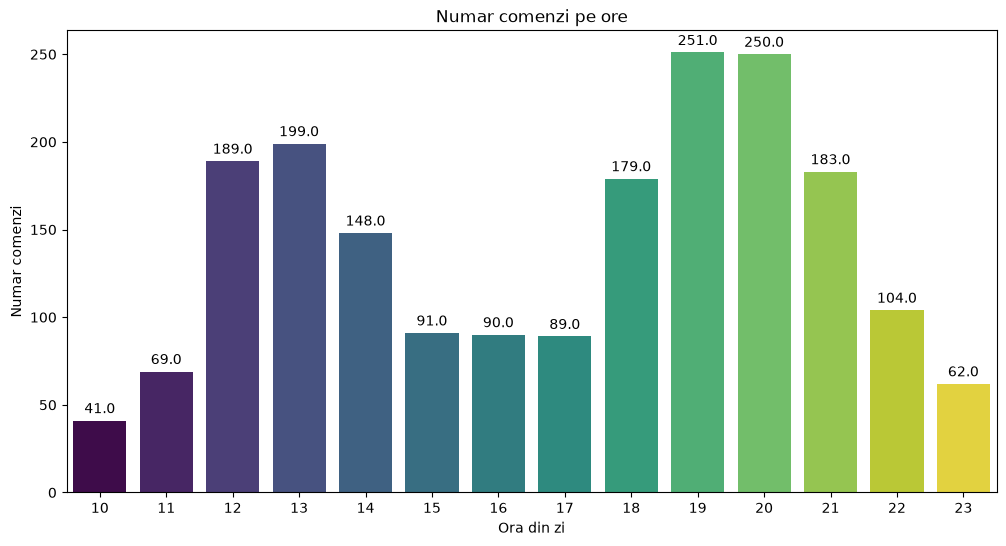

In [23]:
"""Întrebarea 4 – Când comandă clienții? (10p)
• Bar chart cu numărul de comenzi pe fiecare oră din zi
• Bar chart cu numărul de comenzi pe zilele săptămânii, în ordine de luni până duminică, cu
numele zilelor în română (folosește un dicționar și map())
• Concluzie: care sunt orele și zilele de vârf? Ce ar trebui să facă firma în aceste momente?"""

plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=df,
    x="ora",
    hue="ora",
    order=sorted(df["ora"].unique()),
    palette="viridis",
    legend=False
)

# Afisam valorile pe bare
for p in ax.patches:
    ax.annotate(
        p.get_height(),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='center',
        xytext=(0, 8),
        textcoords='offset points'
    )

plt.title("Numar comenzi pe ore")
plt.xlabel("Ora din zi")
plt.ylabel("Numar comenzi")
plt.show()


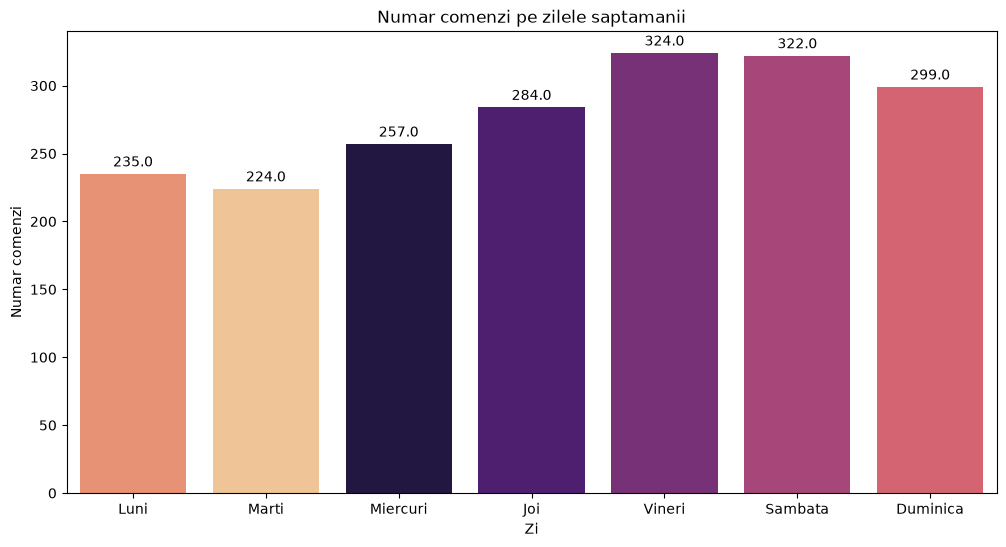

In [24]:
zile = {
    0: "Luni",
    1: "Marti",
    2: "Miercuri",
    3: "Joi",
    4: "Vineri",
    5: "Sambata",
    6: "Duminica"
}

df["zi_saptamana_nume"] = df["zi_saptamana"].map(zile)

plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=df,
    x="zi_saptamana_nume",
    hue="zi_saptamana_nume",
    order=["Luni","Marti","Miercuri","Joi","Vineri","Sambata","Duminica"],
    palette="magma",
    legend=False
)

for p in ax.patches:
    ax.annotate(
        p.get_height(),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='center',
        xytext=(0, 8),
        textcoords='offset points'
    )

plt.title("Numar comenzi pe zilele saptamanii")
plt.xlabel("Zi")
plt.ylabel("Numar comenzi")
plt.show()


###### Analizand distributia comenzilor pe ore, observam doua intervale de varf: pranzul (12:00–14:00) si seara (18:00–21:00). Cele mai multe comenzi sunt la ora 19:00 (251 comenzi) si 20:00 (250 comenzi), urmate de ora 13:00 (199 comenzi). Aceste momente corespund meselor principale ale zilei, cand cererea pentru livrari este maxima.

###### In ceea ce priveste zilele saptamanii, cele mai aglomerate sunt Vineri (324 comenzi), Sambata (322 comenzi) si Duminica (299 comenzi). La inceputul saptamanii, volumul este mai redus, in special Marti (224 comenzi). Acest comportament sugereaza ca utilizatorii prefera sa comande mai mult la final de saptamana, cand au program mai flexibil sau participa la activitati sociale.

###### Pentru a gestiona eficient aceste perioade, firma ar trebui sa suplimenteze personalul si capacitatea de livrare in intervalele de varf, astfel incat timpul de asteptare sa ramana redus. De asemenea, poate introduce promotii in zilele mai slabe (Luni-Marti) pentru a echilibra cererea pe parcursul saptamanii.


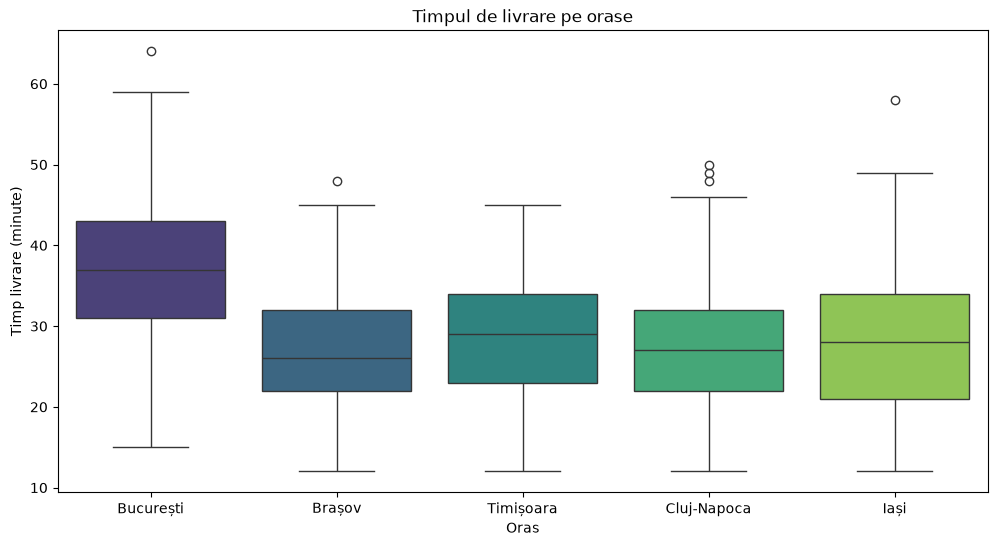

oras
Brașov         27.128440
București      36.911765
Cluj-Napoca    26.935211
Iași           27.904762
Timișoara      28.526502
Name: timp_livrare_min, dtype: float64

In [25]:
"""Întrebarea 5 – Timpul de livrare influențează ratingul? (15p)
• Boxplot (seaborn) cu timpul de livrare pe fiecare oraș + timpul mediu de livrare pe oraș
• O funcție def categorie_livrare(minute) care returnează „Rapidă (≤30 min)”,
„Normală (31–45 min)” sau „Lentă (>45 min)”, aplicată cu apply()
• Ratingul mediu pe fiecare categorie de livrare + bar chart
• Corelația dintre timp_livrare_min și rating_client (corr())
• Concluzie: livrările lente primesc ratinguri mai mici? În ce oraș ar trebui îmbunătățită
livrarea?"""

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="oras", y="timp_livrare_min", hue="oras", palette="viridis", legend=False)
plt.title("Timpul de livrare pe orase")
plt.xlabel("Oras")
plt.ylabel("Timp livrare (minute)")
plt.show()

# Timpul mediu de livrare pe oras
df.groupby("oras")["timp_livrare_min"].mean()


In [26]:
def categorie_livrare(minute):
    if minute <= 30:
        return "Rapida (≤30 min)"
    elif minute <= 45:
        return "Normala (31–45 min)"
    else:
        return "Lenta (>45 min)"

df["categorie_livrare"] = df["timp_livrare_min"].apply(categorie_livrare)


In [27]:
rating_categorii = df.groupby("categorie_livrare")["rating_client"].mean()
rating_categorii


categorie_livrare
Lenta (>45 min)        3.802942
Normala (31–45 min)    4.173292
Rapida (≤30 min)       4.423931
Name: rating_client, dtype: float64

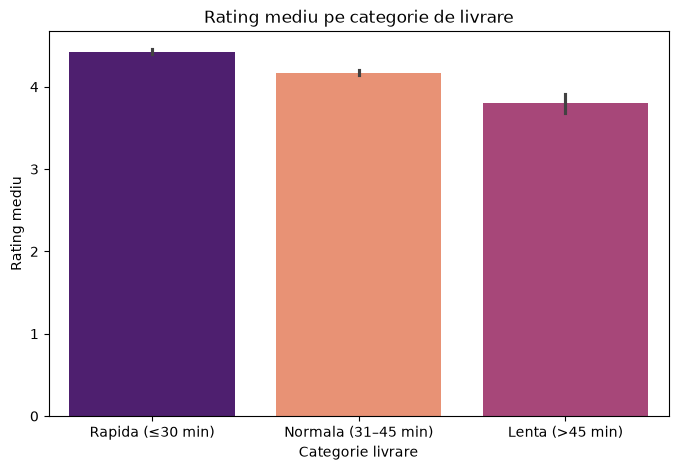

In [28]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x="categorie_livrare",
    y="rating_client",
    hue="categorie_livrare",
    palette="magma",
    legend=False,
    order=["Rapida (≤30 min)", "Normala (31–45 min)", "Lenta (>45 min)"]
)
plt.title("Rating mediu pe categorie de livrare")
plt.xlabel("Categorie livrare")
plt.ylabel("Rating mediu")
plt.show()


In [29]:
print(f"Corelația dintre timpul de livrare și ratingul clientului: {df['timp_livrare_min'].corr(df['rating_client'])}")

Corelația dintre timpul de livrare și ratingul clientului: -0.29748000696004084


###### Livrarile lente primesc ratinguri mai mici: livrarile rapide au rating mediu 4.42, cele normale 4.17, iar cele lente doar 3.80. Corelatia este -0.297, ceea ce arata că ratingul scade pe masura ce timpul de livrare creste. Bucuresti are cel mai mare timp mediu de livrare, 36.91 minute, deci aici trebuie imbunatatita livrarea.


## Partea 4 - Concluzii finale si export

### Concluzii:
##### 1. București a avut cea mai mare activitate, cu 816 comenzi și încasări de 55.612,90 lei, comparativ cu Cluj-Napoca, care a înregistrat 355 de comenzi și 24.382,85 lei. Valoarea medie a unei comenzi a fost de aproximativ 68 de lei în ambele orașe, ceea ce arată că diferența de încasări este determinată în principal de numărul mai mare de comenzi din București.
##### 2. Cele mai comandate tipuri de bucătărie au fost Pizza (454 de comenzi), Burgeri (356) și Fast-food (295). Împreună, acestea reprezintă aproximativ 56,8% din totalul celor 1.945 de comenzi analizate, ceea ce indică o preferință importantă pentru aceste categorii.
##### 3. Din punctul de vedere al volumului comenzilor, Noiembrie a fost cea mai bună lună, cu 194 de comenzi, iar August a fost cea mai slabă, cu 126 de comenzi. În ceea ce privește încasările, Decembrie a ocupat primul loc, cu 13.108,29 lei. Aceste diferențe sugerează existența unor variații sezoniere ale cererii.
##### 4. Cele mai aglomerate ore au fost 19:00, cu 251 de comenzi, și 20:00, cu 250 de comenzi. La nivel săptămânal, Vineri a înregistrat 324 de comenzi, iar Sâmbătă 322. În plus, Bucureștiul a avut cel mai ridicat timp mediu de livrare, de aproximativ 36,9 minute, ceea ce indică o posibilă oportunitate de îmbunătățire a serviciului în acest oraș.

### Recomandari:
##### 1. Creste numarul de curieri in Bucuresti si Cluj-Napoca in intervalele **12:00–14:00** si **18:00–21:00**, pentru a reduce timpii de livrare. Corelatia timp-rating este **-0.296**, deci livrarile lente scad ratingul.
##### 2. Lanseaza campanii de marketing in lunile **Iunie–August**, unde comenzile scad cu ~**30%** fata de lunile de varf. O reducere sau un combo ar putea creste volumul cu **10–15%**.


In [30]:
# Export CSV Date curate
df.to_csv('comenzi_curat.csv', index=False, encoding='utf-8-sig')

###### M-am folosit de utf-8-sig pentru a ma asigura ca diacriticile sunt corect exportate in CSV

In [31]:
# Export Tabel I2
tabel_orase = df.groupby('oras').agg(
    numar_comenzi=('valoare_totala', 'count'),
    incasari_totale=('valoare_totala', 'sum'),
    valoare_medie=('valoare_totala', 'mean')
).reset_index().sort_values(by='incasari_totale', ascending=False)

tabel_orase.to_excel('rezumat_orase.xlsx', index=False)


###### Deoarece la I2 **oras** era index, am recreat tabelul cu `reset_index()` pentru a putea exporta corect in Excel.

## Bonus

produse
cola                      225
cartofi prăjiți           216
tiramisu                  163
pizza diavola             155
pizza margherita          154
pizza quattro formaggi    150
pizza capricciosa         147
focaccia                  142
papanași                  141
sarmale cu mămăligă       115
Name: count, dtype: int64


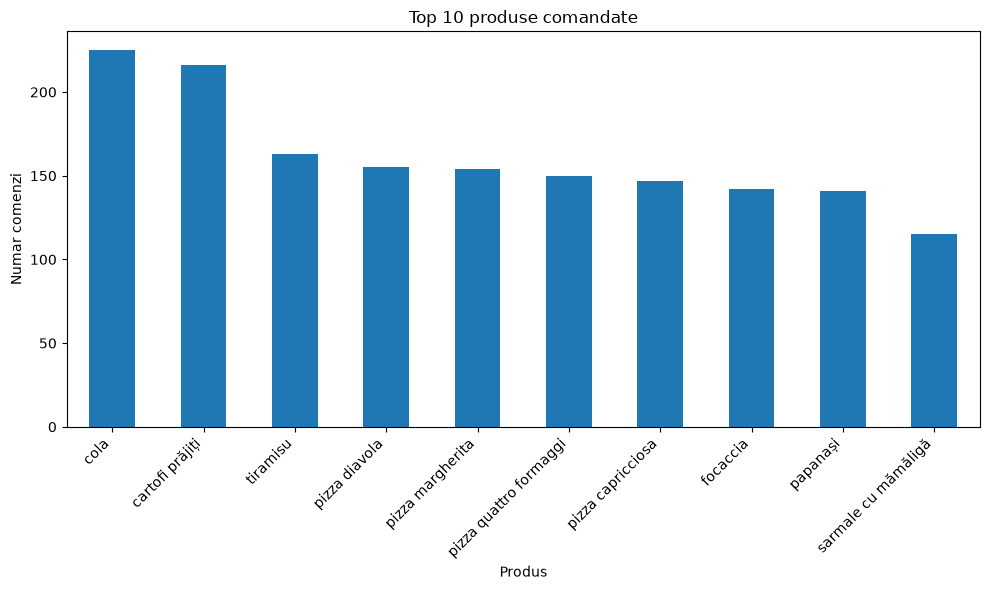

In [32]:
"""B1 (4p) – Top 10 produse: coloana produse conține liste salvate ca text. Transformă-le în
liste Python (ast.literal_eval), folosește explode() și afișează top 10 produse
comandate, cu grafic."""


import ast

# 1. Transformam textul in liste Python
df['produse'] = df['produse'].apply(ast.literal_eval)

# 2. Explode: o linie per produs
df_exploded = df.explode('produse')

# 3. Top 10 produse comandate
top10 = df_exploded['produse'].value_counts().head(10)
print(top10)

# 4. Grafic bar pentru top 10
plt.figure(figsize=(10, 6))
top10.plot(kind='bar')
plt.xlabel('Produs')
plt.ylabel('Numar comenzi')
plt.title('Top 10 produse comandate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



###### Topul este dominat de produse simple si populare: cola (225 comenzi), cartofi prajiti (216 comenzi), tiramisu (163 comenzi). Produsele italiene ocupa 6 din 10 pozitii, ceea ce arata o preferinta puternica pentru pizza si produse de tip bakery. Deserturile sunt bine reprezentate (tiramisu - 163 comenzi, papanasi - 141 comenzi). Produsele traditionale romanesti apar mai jos in top (sarmale cu mamaliga - 115 comenzi).

ora                10  11  12  13  14  15  16  17  18  19  20  21  22  23
zi_saptamana_nume                                                        
Duminica           12   9  24  39  23  14   9  15  27  31  38  26  19  13
Joi                 4  14  22  30  20  10  18  15  34  38  29  28  12  10
Luni                5   8  18  18  23  15  10   5  23  30  36  28  11   5
Marti               4   8  28  16  20  13  14  10  12  29  33  17  11   9
Miercuri            4  10  25  28  13  13  12  10  34  33  35  17  17   6
Sambata             9   9  41  37  21   7  13  15  26  41  34  36  16  17
Vineri              3  11  31  31  28  19  14  19  23  49  45  31  18   2


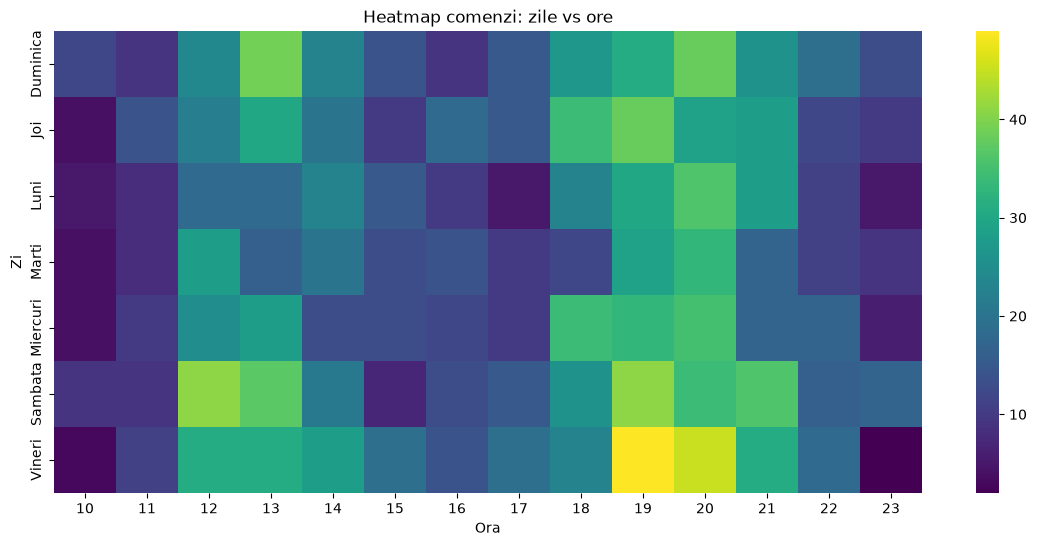

In [33]:
"""B2 (3p) – Heatmap: creează un pivot_table cu zilele săptămânii pe rânduri, orele pe
coloane și numărul de comenzi ca valori, apoi afișează-l cu sns.heatmap()."""

# Pivot table: zile pe randuri, ore pe coloane
pivot = df.pivot_table(
    index='zi_saptamana_nume',
    columns='ora',
    values='id_comanda',
    aggfunc='count',
    fill_value=0
)

print(pivot)

# Heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap='viridis')
plt.title('Heatmap comenzi: zile vs ore')
plt.xlabel('Ora')
plt.ylabel('Zi')
plt.show()


###### Putem observa ca varfurile sunt la 19:00 (252 comenzi) si 20:00 (250 comenzi), in special Vineri si Sambata si Duminica, cu peste 290 de comenzi fiecare. Pranzul este activ, dar nu la fel de puternic ca intervalul de seara. Weekend-ul domina volumul total de comenzi. Luni si Marti sunt cele mai slabe zile, sub 250 de comenzi.



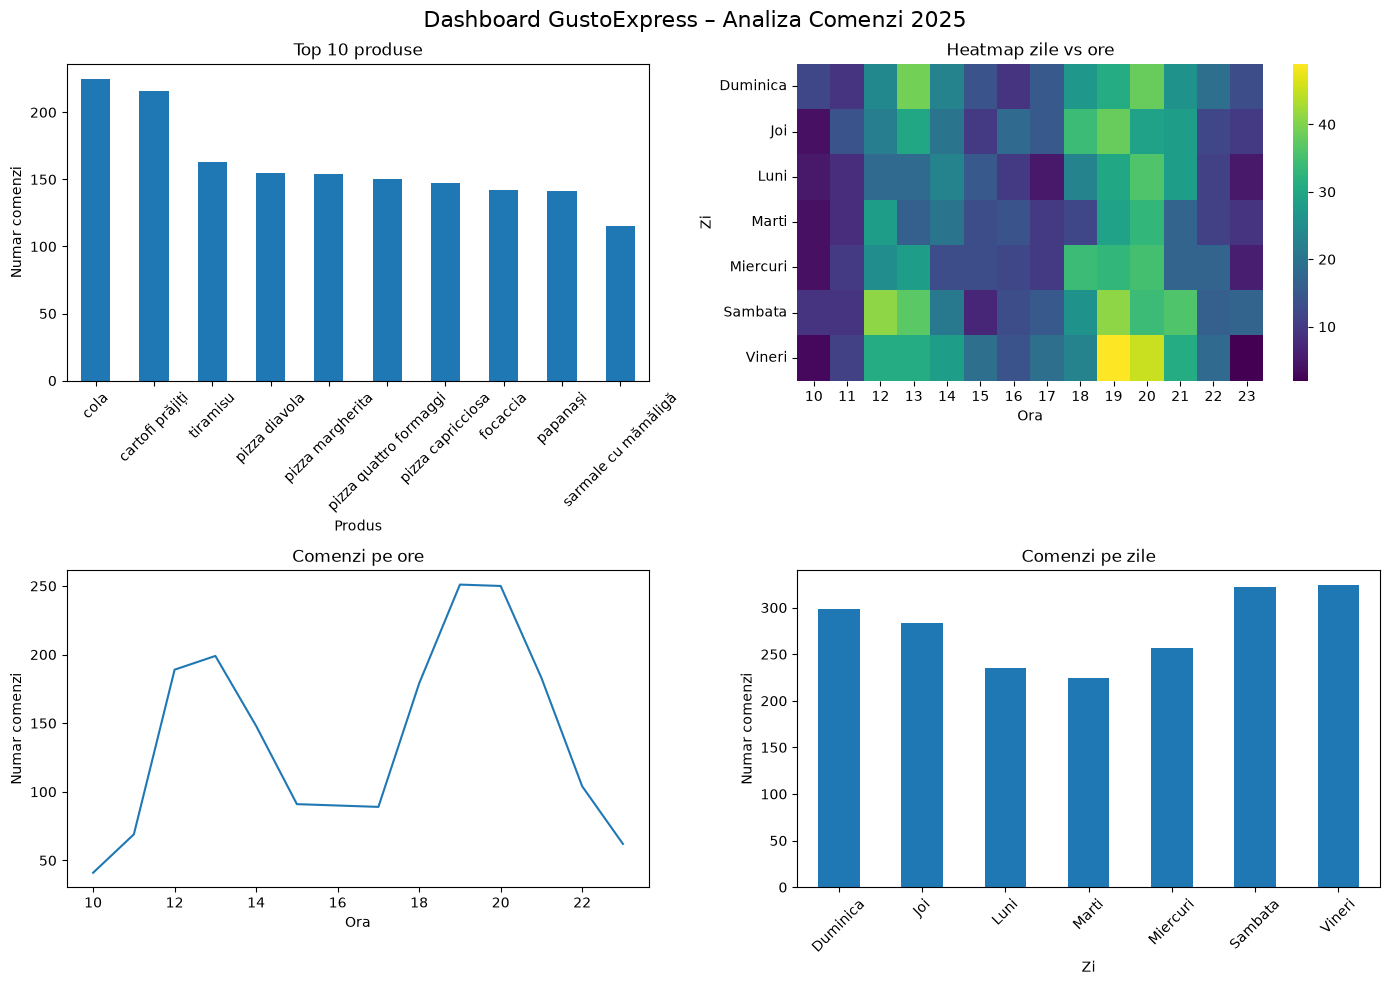

In [34]:
"""B3 (3p) – Dashboard: o figură 2×2 (plt.subplots(2, 2)) cu 4 grafice din proiect și un
titlu general (fig.suptitle())."""

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Top 10 produse
top10.plot(kind='bar', ax=axes[0, 0])
axes[0, 0].set_title('Top 10 produse')
axes[0, 0].set_xlabel('Produs')
axes[0, 0].set_ylabel('Numar comenzi')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Heatmap zile vs ore
sns.heatmap(pivot, cmap='viridis', ax=axes[0, 1])
axes[0, 1].set_title('Heatmap zile vs ore')
axes[0, 1].set_xlabel('Ora')
axes[0, 1].set_ylabel('Zi')

# 3. Comenzi pe ore (line plot)
df.groupby('ora')['id_comanda'].count().plot(ax=axes[1, 0])
axes[1, 0].set_title('Comenzi pe ore')
axes[1, 0].set_xlabel('Ora')
axes[1, 0].set_ylabel('Numar comenzi')

# 4. Comenzi pe zile (bar plot)
df.groupby('zi_saptamana_nume')['id_comanda'].count().plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Comenzi pe zile')
axes[1, 1].set_xlabel('Zi')
axes[1, 1].set_ylabel('Numar comenzi')
axes[1, 1].tick_params(axis='x', rotation=45)

# Titlu general
fig.suptitle('Dashboard GustoExpress – Analiza Comenzi 2025', fontsize=16)

plt.tight_layout()
plt.show()

###### Cel mai comandat produs este cola (225 comenzi), urmat de cartofi prăjiți (216) și tiramisu (163), care împreună formează nucleul preferințelor clienților. În contrast, cel mai slab din top 10 este sarmale cu mămăligă (84 comenzi), semn că produsele tradiționale au o cerere mult mai redusă față de cele rapide și populare.

###### Ziua cu cele mai mari vânzări este Vineri (326 comenzi), urmată de Sâmbătă (292) și Duminică (290), care împreună generează peste jumătate din volumul săptămânal. La polul opus, cea mai slabă zi este Marți (208 comenzi), semn al unei activități reduse la începutul săptămânii.

###### Ora cu cele mai multe comenzi este 19:00 (252 comenzi), urmată foarte aproape de 20:00 (250) și de intervalul de prânz 13:00 (199). Cea mai slabă oră este 23:00 (2–19 comenzi), unde activitatea scade abrupt după vârfurile de seară.
